# Mini-Project 2: Solar Micro-Grid Dispatch Planner

**Scenario.** A rural health centre in Kasese runs a micro-grid. Each day the energy drawn from solar panels (x, kWh) and batteries (y, kWh) must satisfy

$$3x + 2y = D_1 \quad\text{(daytime load)} \qquad 4x + y = D_2 \quad\text{(critical-equipment load)}$$

**My approach.**
1. Wrap the linear system in a `MicroGrid` class (`src/microgrid.py`) that checks the system is well-posed *before* solving.
2. Support validated interactive input and a seeded, synthetic 30-day CSV.
3. Solve all days with a loop and with one vectorised call, and time both.
4. Detect physically impossible (negative) dispatches and repair them with non-negative least squares.
5. Describe the dispatch statistically, cost it, and plot it.
6. Extensions: a diesel generator (`HybridMicroGrid` subclass) and Monte Carlo sensitivity analysis.

**Assumptions.** The coefficients come from the brief. Demand values are *illustrative* (synthetic) and in kWh. Tariffs are UGX 150/kWh (solar) and UGX 450/kWh (battery), as given.

In [1]:
import timeit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.microgrid import (CostModel, HybridMicroGrid, MicroGrid, generate_demand_csv,
                           load_demand_csv, monte_carlo_sensitivity, prompt_demand,
                           usage_statistics)

SEED = 42
DATA_PATH = "data/microgrid_demand.csv"
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110})

## Task 1: The `MicroGrid` class and well-posedness

In [2]:
grid = MicroGrid()
print(grid)
print("A =\n", grid.A)
print(f"det(A)  = {grid.determinant():.4f}   (hand: 3*1 - 2*4 = -5)")
print(f"cond(A) = {grid.condition_number():.4f}   (exact value 3 + 2*sqrt(2) = {3 + 2 * np.sqrt(2):.4f})")
print("well-posed:", grid.is_well_posed())

MicroGrid(sources=('solar', 'battery'), det=-5, cond=5.83)
A =
 [[3. 2.]
 [4. 1.]]
det(A)  = -5.0000   (hand: 3*1 - 2*4 = -5)
cond(A) = 5.8284   (exact value 3 + 2*sqrt(2) = 5.8284)
well-posed: True


**What these numbers mean.**

* **Determinant = −5 ≠ 0.** The two equations are linearly independent, so for *any* pair of demands there is exactly **one** dispatch (x, y). If the determinant were 0, the two constraints would be parallel lines: either no solution or infinitely many. The sign only tells us the orientation; what matters is that the value is far from zero.
* **Condition number ≈ 5.83.** The condition number κ(A) = σ_max/σ_min bounds how much a relative error in the demands can be amplified in the solution: ‖Δs‖/‖s‖ ≤ κ · ‖Δd‖/‖d‖. A κ of about 6 is small (well-conditioned), so a 1 % metering error moves the solution by at most about 6 % *in norm*. Numerically this system is very safe. Its κ is nowhere near the 10¹⁰ range where floating-point results become untrustworthy.

Solving by hand gives closed forms that I use as a second-method check throughout:
x = (2·D₂ − D₁)/5 and y = (4·D₁ − 3·D₂)/5.
So the dispatch is physically feasible (x, y ≥ 0) **only when 0.75·D₂ ≤ D₁ ≤ 2·D₂**.

In [3]:
d1, d2 = 100.0, 60.0
x, y = grid.solve_day(d1, d2)
print(f"solve_day({d1}, {d2}) -> solar x = {x:.2f} kWh, battery y = {y:.2f} kWh")
print("hand formula   ->", (2 * d2 - d1) / 5, (4 * d1 - 3 * d2) / 5)
print("residual A@s - d =", grid.A @ np.array([x, y]) - [d1, d2])

solve_day(100.0, 60.0) -> solar x = 4.00 kWh, battery y = 44.00 kWh
hand formula   -> 4.0 44.0
residual A@s - d = [0. 0.]


## Task 2: Two input modes

### (a) Interactive input with validation
`prompt_demand` keeps asking until it gets a valid number. It rejects **empty**, **non-numeric** (including `nan`/`inf`) and **negative** values. The input function is *injected* as a parameter. That lets the notebook run unattended under *Restart & Run All*, and it lets pytest test the loop. Below I feed it a scripted list of bad answers followed by a good one. To use it interactively, call `prompt_demand("D1 (kWh): ")` with the default `input`.

In [4]:
def scripted(answers):
    it = iter(answers)
    def fake_input(prompt):
        value = next(it)
        print(f"{prompt}{value!r}")
        return value
    return fake_input

INTERACTIVE = False   # set True to type values yourself
if INTERACTIVE:
    d1 = prompt_demand("D1 daytime load (kWh): ")
    d2 = prompt_demand("D2 critical load (kWh): ")
else:
    d1 = prompt_demand("D1 daytime load (kWh): ", input_fn=scripted(["", "lots", "-20", "96.5"]))
    d2 = prompt_demand("D2 critical load (kWh): ", input_fn=scripted(["sixty", "58"]))
print("\nAccepted:", d1, d2, "->", grid.solve_day(d1, d2).round(2))

D1 daytime load (kWh): ''
  Invalid input: no value entered. Please try again.
D1 daytime load (kWh): 'lots'
  Invalid input: 'lots' is not a number. Please try again.
D1 daytime load (kWh): '-20'
  Invalid input: demand cannot be negative. Please try again.
D1 daytime load (kWh): '96.5'
D2 critical load (kWh): 'sixty'
  Invalid input: 'sixty' is not a number. Please try again.
D2 critical load (kWh): '58'

Accepted: 96.5 58.0 -> [ 3.9 42.4]


### (b) 30 days from a CSV

I generate the CSV myself with `np.random.default_rng(42)`. **Assumptions about the load profile:**
* **D₁ (daytime load)** is about 105 kWh on weekdays (outpatient clinic, lab, admin) and about 80 kWh at weekends, with noise σ = 8 kWh.
* **D₂ (critical load)** covers vaccine fridges, oxygen concentrators and maternity lighting. It runs every day at about 58 kWh, plus 3 kWh on weekdays, with noise σ = 4 kWh.

These ratios sit inside the feasible band most of the time, but noise sometimes pushes a weekday past D₁ > 2·D₂. That is realistic: some days demand simply cannot be met with this source mix.

In [5]:
generate_demand_csv(DATA_PATH, days=30, seed=SEED)
demand = load_demand_csv(DATA_PATH)
demand["weekday"] = pd.to_datetime(demand["date"]).dt.day_name().str[:3]
display(demand.head(8))
print(demand[["D1", "D2"]].describe().loc[["mean", "std", "min", "max"]])

,date,D1,D2,weekday
0,2026-09-01,107.40,69.60,Tue
1,2026-09-02,96.70,59.40,Wed
2,2026-09-03,111.00,59.00,Thu
3,2026-09-04,112.50,57.70,Fri
4,2026-09-05,64.40,60.50,Sat
5,2026-09-06,69.60,62.50,Sun
6,2026-09-07,106.00,60.50,Mon
7,2026-09-08,102.50,57.60,Tue


         D1    D2
mean  98.47 60.66
std   13.64  3.44
min   64.40 55.20
max  114.80 69.60


## Task 3: Loop vs vectorised solve (timed with `timeit`)

In [6]:
D = demand[["D1", "D2"]].to_numpy()          # shape (30, 2)
loop_sol = grid.solve_days_loop(D)           # 30 calls to scipy.linalg.solve
vec_sol = grid.solve_days_vectorised(D)      # one call with a 2x30 right-hand side
assert np.allclose(loop_sol, vec_sol)

n = 500
t_loop = timeit.timeit(lambda: grid.solve_days_loop(D), number=n) / n
t_vec = timeit.timeit(lambda: grid.solve_days_vectorised(D), number=n) / n
print(f"loop:       {t_loop * 1e6:8.1f} us per 30 days")
print(f"vectorised: {t_vec * 1e6:8.1f} us per 30 days")
print(f"speed-up:   {t_loop / t_vec:.1f}x")

loop:         2514.9 us per 30 days
vectorised:    467.0 us per 30 days
speed-up:   5.4x


**Comment.** Both methods give identical answers (checked with `np.allclose`), but the vectorised call is several times faster. The arithmetic for a 2×2 system is trivial. Almost all the time in the loop goes on **per-call overhead**: input validation inside `scipy.linalg.solve`, Python function calls, and allocating 30 tiny arrays. The vectorised version pays that overhead once, factorises A once (LU decomposition), and then back-substitutes all 30 right-hand sides in compiled code. The absolute times here are microseconds, so for 30 days it does not matter in practice. The gap matters for the Monte Carlo below (thousands of solves) or for a utility dispatching thousands of sites.

## Task 4: Physically infeasible days

A negative x or y would mean the panels or batteries *absorb* energy while still meeting the load, which the constraints do not allow. **My handling strategy:**
1. Flag the day (`feasible = False`) and keep the raw exact solution for the report.
2. Re-solve with `scipy.optimize.nnls`, which finds the non-negative dispatch that comes **closest** to meeting both constraints (least squares).
3. Report the remaining shortfall (`residual_kwh` = ‖A·s − d‖), so the manager knows how much load was unmet and can shed non-critical load or start a backup generator.

I prefer this to simple clipping. Clipping a negative value to 0 leaves the other source unchanged, so *both* constraints are then violated by an arbitrary amount. NNLS chooses the best possible compromise.

In [7]:
dispatch = grid.dispatch(D, dates=demand["date"])
infeasible = dispatch[~dispatch["feasible"]]
print(f"{len(infeasible)} infeasible day(s) out of {len(dispatch)}")
display(infeasible[["date", "D1", "D2", "solar_exact", "battery_exact", "solar", "battery", "residual_kwh"]])
for _, row in infeasible.iterrows():
    print(f"{row['date']}: D1/D2 = {row['D1'] / row['D2']:.2f} > 2, so solar would need to be "
          f"{row['solar_exact']:.2f} kWh. NNLS uses solar={row['solar']:.2f}, battery={row['battery']:.2f}; "
          f"unmet {row['residual_kwh']:.2f} kWh (norm)")
    # compare with naive clipping
    clipped = np.clip([row["solar_exact"], row["battery_exact"]], 0, None)
    print(f"   clipping instead would leave residual {np.linalg.norm(grid.A @ clipped - [row['D1'], row['D2']]):.2f} kWh")

1 infeasible day(s) out of 30


,date,D1,D2,solar_exact,battery_exact,solar,battery,residual_kwh
22,2026-09-23,114.80,55.20,-0.88,58.72,0.00,56.96,1.97


2026-09-23: D1/D2 = 2.08 > 2, so solar would need to be -0.88 kWh. NNLS uses solar=0.00, battery=56.96; unmet 1.97 kWh (norm)
   clipping instead would leave residual 4.40 kWh


## Task 5: Statistics of solar and battery usage

In [8]:
usage = pd.DataFrame({src: usage_statistics(dispatch[src]) for src in grid.sources}).T
usage.columns = ["mean (kWh)", "variance (kWh²)", "stdev (kWh)", "CV"]
usage

,mean (kWh),variance (kWh²),stdev (kWh),CV
solar,4.60,7.15,2.67,0.58
battery,42.32,110.20,10.50,0.25


**Which source is more volatile?** In *absolute* terms the battery swings more (σ ≈ 10.5 kWh vs ≈ 2.7 kWh), but it also carries roughly nine times more energy. Relative to its own level, **solar is far more volatile (CV ≈ 0.58 vs ≈ 0.25)**. Solar is computed as a small difference of two large numbers (2·D₂ − D₁), so modest changes in demand cause large proportional swings. I treat the CV as the fair comparison because it is unit-free and adjusts for scale. The variance in kWh² cannot be compared across sources of different size.

A side observation: with these coefficients the battery does most of the work on every day. That is a consequence of the given equations, not of the data. It is economically awkward because battery energy is three times dearer.

## Task 6: Cost model

In [9]:
cost = CostModel({"solar": 150, "battery": 450})
dispatch["cost_ugx"] = cost.daily_cost(dispatch)
monthly = cost.monthly_cost(dispatch)
print(f"Mean daily cost:  UGX {dispatch['cost_ugx'].mean():,.0f}")
print(f"Min / max daily:  UGX {dispatch['cost_ugx'].min():,.0f} / {dispatch['cost_ugx'].max():,.0f}")
print(f"Monthly (30 days): UGX {monthly:,.0f}")
print(f"Battery share of cost: {(dispatch['battery'] * 450).sum() / monthly:.1%}")
# hand check, day 1
r = dispatch.iloc[0]
print(f"Day 1 check: {r['solar']:.2f}*150 + {r['battery']:.2f}*450 = {r['solar'] * 150 + r['battery'] * 450:,.0f}")

Mean daily cost:  UGX 19,734
Min / max daily:  UGX 8,547 / 25,632
Monthly (30 days): UGX 592,023
Battery share of cost: 96.5%
Day 1 check: 6.36*150 + 44.16*450 = 20,826


## Task 7: Stacked bar chart with daily cost on a second axis

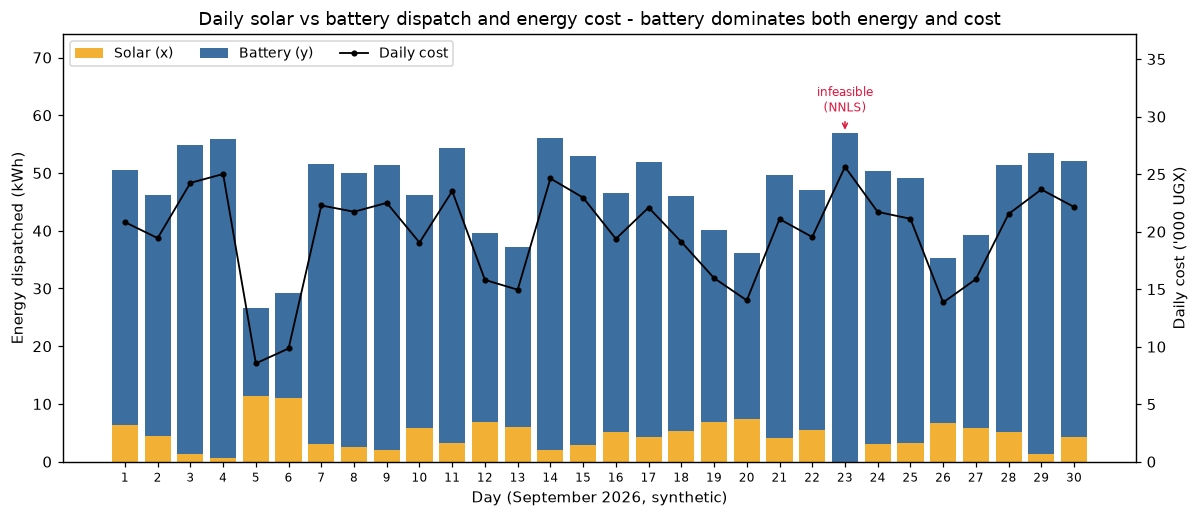

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.8))
days = np.arange(1, len(dispatch) + 1)
ax.bar(days, dispatch["solar"], color="#f2b134", label="Solar (x)")
ax.bar(days, dispatch["battery"], bottom=dispatch["solar"], color="#3c6e9f", label="Battery (y)")
bad_days = days[~dispatch["feasible"].to_numpy()]
for d in bad_days:
    ax.annotate("infeasible\n(NNLS)", (d, dispatch["solar"].iloc[d - 1] + dispatch["battery"].iloc[d - 1]),
                xytext=(0, 14), textcoords="offset points", ha="center", fontsize=8, color="crimson",
                arrowprops=dict(arrowstyle="->", color="crimson"))
ax.set_ylim(0, (dispatch["solar"] + dispatch["battery"]).max() * 1.3)
ax.set_xlabel("Day (September 2026, synthetic)")
ax.set_ylabel("Energy dispatched (kWh)")
ax.set_xticks(days)
ax.tick_params(axis="x", labelsize=8)
ax2 = ax.twinx()
ax2.plot(days, dispatch["cost_ugx"] / 1000, color="black", marker="o", ms=3, lw=1.2, label="Daily cost")
ax2.set_ylabel("Daily cost ('000 UGX)")
ax2.set_ylim(0, dispatch["cost_ugx"].max() / 1000 * 1.45)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", ncol=3, fontsize=9)
ax.set_title("Daily solar vs battery dispatch and energy cost - battery dominates both energy and cost")
fig.tight_layout()
fig.savefig("figures/p2_dispatch_cost.png", bbox_inches="tight")
plt.show()

The chart shows the weekly rhythm (weekend dips in total energy and cost), the battery's dominance, and the cost line tracking battery use almost exactly, because battery energy is three times the price of solar.

## Extension A: `HybridMicroGrid` with a diesel generator

**Third constraint (my choice).** I add diesel z and a total-energy constraint, and diesel also enters the first two loads:

| Equation | Meaning |
|---|---|
| 3x + 2y + 1z = D₁ | daytime load; diesel contributes a little |
| 4x + 1y + 2z = D₂ | critical load; diesel is the designated backup |
| x + y + z = D₃ | total energy the centre plans to draw |

`HybridMicroGrid` **inherits** all the solving, feasibility and NNLS logic from `MicroGrid` and only changes the defaults and size check. No code is duplicated.

In [11]:
hybrid = HybridMicroGrid()
print(hybrid)
s = hybrid.solve_day(105, 61, 53)
print("solve_day(105, 61, 53) -> solar, battery, diesel =", s.round(2))
print("check A@s =", (hybrid.A @ s).round(6))

# Which D3 values give a feasible (all non-negative) dispatch for D1=105, D2=61?
d3_grid = np.linspace(0, 80, 801)
sols = hybrid.solve_days_vectorised(np.column_stack([np.full_like(d3_grid, 105), np.full_like(d3_grid, 61), d3_grid]))
ok = d3_grid[np.all(sols >= 0, axis=1)]
print(f"feasible D3 range: {ok.min():.1f} to {ok.max():.1f} kWh")

HybridMicroGrid(sources=('solar', 'battery', 'diesel'), det=-4, cond=10.1)
solve_day(105, 61, 53) -> solar, battery, diesel = [ 1.75 48.5   2.75]
check A@s = [105.  61.  53.]
feasible D3 range: 50.8 to 55.3 kWh


For a typical weekday (D₁ = 105, D₂ = 61), only total-energy targets of about **51–55 kWh** give a dispatch where all three sources are non-negative. Outside that window one source must go negative, and NNLS (inherited from `MicroGrid.dispatch`) would be needed. An exactly determined 3×3 system leaves the operator **no freedom**: once D₃ is fixed, the diesel share is fixed too. That is another reason real dispatch is framed as an optimisation problem.

In [12]:
# What if the third equation is linearly dependent on the first two?
dependent = HybridMicroGrid([[3, 2, 1], [4, 1, 2], [7, 3, 3]])   # row 3 = row 1 + row 2
print("det =", round(dependent.determinant(), 12), "| cond =", f"{np.linalg.cond(dependent.A):.2e}")
try:
    dependent.solve_day(105, 61, 166)
except np.linalg.LinAlgError as err:
    print("LinAlgError:", err)

det = 0.0 | cond = 2.48e+16
LinAlgError: coefficient matrix is singular (det=2.22e-15); the constraints are linearly dependent, so there is no unique dispatch


**Linear dependence.** If the third row is a combination of the others (here row₃ = row₁ + row₂), then det(A) = 0 and κ(A) is effectively infinite. The third equation adds **no new information**. Two things can happen:
* If D₃ = D₁ + D₂ (a consistent RHS), there are **infinitely many** dispatches: one free degree of freedom along a line.
* If D₃ ≠ D₁ + D₂, there is **no** dispatch at all (the constraints contradict each other).

Either way, `solve` cannot return a unique answer. My class checks the determinant first and raises a clear `LinAlgError` instead of returning garbage. To resolve a real dependent system, the planner must add a genuinely independent constraint (e.g. a diesel fuel limit) or turn it into an optimisation problem, e.g. minimise cost subject to the constraints with `scipy.optimize.linprog`.

## Extension B: Monte Carlo sensitivity (±5 %, 1,000 draws)

In [13]:
base_d = np.array([105.0, 61.0])        # a typical weekday
base_s = grid.solve_day(*base_d)
mc = monte_carlo_sensitivity(grid, base_d, rel=0.05, n_draws=1000, seed=SEED)

rel_in = np.linalg.norm(mc[["D1", "D2"]].to_numpy() - base_d, axis=1) / np.linalg.norm(base_d)
rel_out = np.linalg.norm(mc[["solar", "battery"]].to_numpy() - base_s, axis=1) / np.linalg.norm(base_s)
amplification = rel_out / rel_in

summary = pd.DataFrame({
    "base (kWh)": base_s,
    "MC mean": mc[["solar", "battery"]].mean().to_numpy(),
    "MC stdev": mc[["solar", "battery"]].std().to_numpy(),
    "2.5%": mc[["solar", "battery"]].quantile(0.025).to_numpy(),
    "97.5%": mc[["solar", "battery"]].quantile(0.975).to_numpy(),
    "max |rel change|": (mc[["solar", "battery"]] - base_s).abs().max().to_numpy() / base_s,
}, index=["solar", "battery"])
display(summary)
print(f"Share of draws with negative solar: {(mc['solar'] < 0).mean():.1%}")
print(f"Norm-wise amplification ||ds||/||s|| / ||dd||/||d||: median {np.median(amplification):.2f}, "
      f"max {amplification.max():.2f}  (bound = cond = {grid.condition_number():.2f})")

,base (kWh),MC mean,MC stdev,2.5%,97.5%,max |rel change|
solar,3.40,3.41,0.91,1.70,5.18,0.64
battery,47.40,47.38,2.65,42.67,52.12,0.12


Share of draws with negative solar: 0.0%
Norm-wise amplification ||ds||/||s|| / ||dd||/||d||: median 2.03, max 2.76  (bound = cond = 5.83)


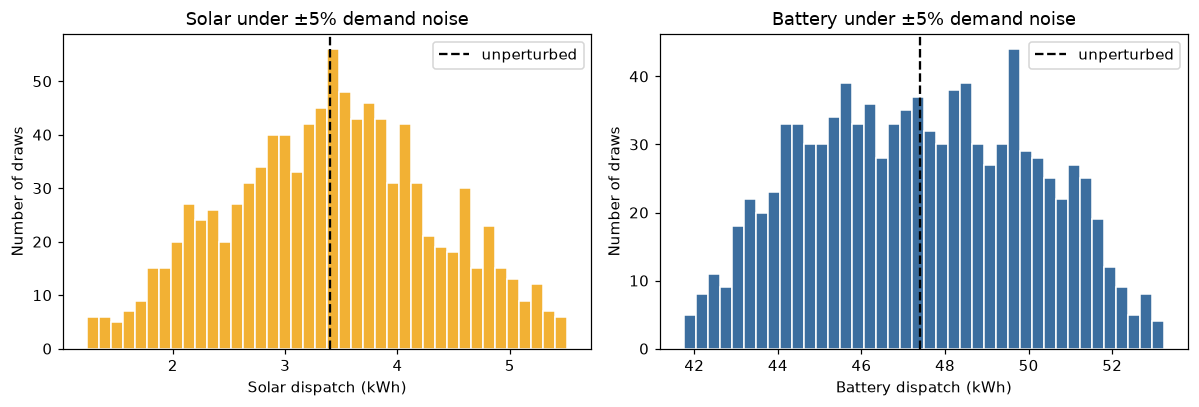

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, src, col in zip(axes, ["solar", "battery"], ["#f2b134", "#3c6e9f"]):
    ax.hist(mc[src], bins=40, color=col, edgecolor="white")
    ax.axvline(base_s[grid.sources.index(src)], color="black", ls="--", label="unperturbed")
    ax.set_xlabel(f"{src.capitalize()} dispatch (kWh)")
    ax.set_ylabel("Number of draws")
    ax.set_title(f"{src.capitalize()} under ±5% demand noise")
    ax.legend()
fig.tight_layout()
fig.savefig("figures/p2_sensitivity.png", bbox_inches="tight")
plt.show()

**Relating this to the condition number.** The norm-wise amplification never exceeds κ ≈ 5.83, exactly as theory guarantees. Its median is much lower because random perturbations rarely line up with the worst-case direction. However, the **components** behave very differently. Battery (the large component) moves by at most about 12 %, but **solar can move by about 64 %**, and its 95 % band spans roughly 1.7 to 5.2 kWh around a base of 3.4. The condition number bounds the error of the *whole vector* relative to its *whole size*. A small component such as solar (3.4 kWh = (2·61 − 105)/5) suffers from **cancellation**: two large, uncertain numbers are subtracted. A low κ therefore guarantees numerical stability, but not that every individual output is robust to measurement error.

## Findings & Limitations

**Findings.** The dispatch system is mathematically well-posed (det = −5) and well-conditioned (κ ≈ 5.8), so solving it is numerically safe. Vectorising the 30-day solve gives the same answers several times faster, because the time goes on per-call overhead rather than arithmetic. The bigger finding is practical: under these coefficients the **battery supplies about 90 % of the energy**, and since it costs three times as much as solar, it accounts for almost all of the roughly UGX 0.6 million monthly bill. Solar is the most volatile source relative to its size (CV ≈ 0.58). The Monte Carlo shows why: solar is a small difference of two large demands, so ±5 % metering noise can move it by about 64 %, even though the system as a whole only amplifies errors by at most 5.8×. One day in thirty was physically infeasible (daytime load more than twice the critical load). NNLS gave the closest non-negative dispatch and reported the unmet energy, which is more honest than clipping.

**Limitations.** The demand data are synthetic, and the coefficients are taken from the brief without physical justification. In reality a dispatch problem has more unknowns than equations and is solved by *optimisation* (minimise cost subject to battery state-of-charge, solar irradiance limits and inverter capacity), not by an exactly determined linear system. The model has no time coupling: batteries must be recharged by solar, so tomorrow's battery energy depends on today's solar surplus. Tariffs are illustrative, and there is no weather or seasonal (rainy-season irradiance) effect. My diesel constraint is also an assumption, chosen to illustrate the 3×3 case.